In [1]:
%load_ext autoreload
%autoreload 2


In [2]:
from dotenv import load_dotenv
import os
import langgraph.config as langgraph_config

load_dotenv()


True

In [3]:
import sqlite3
from langgraph.checkpoint.sqlite import SqliteSaver
from langgraph.checkpoint.serde.jsonplus import JsonPlusSerializer
from graph_states import LearnerProfileState

# 1. Mount serialization whitelisting
custom_serde = JsonPlusSerializer(allowed_msgpack_modules=[LearnerProfileState])

# 2. Open a pristine file connection pool
db_connection = sqlite3.connect("./skillforge_storage.db", check_same_thread=False)

# 3. Re-instantiate the persistent saver
db_checkpointer = SqliteSaver(conn=db_connection, serde=custom_serde)

# 4. Re-run setup to verify schema state
db_checkpointer.setup()
db_connection.commit()
print("💾 SQLite Checkpointer successfully re-hydrated from disk file!")




💾 SQLite Checkpointer successfully re-hydrated from disk file!


In [4]:
from typing import Any, Dict
from langchain_core.messages import HumanMessage, SystemMessage, AIMessage
from langgraph.checkpoint.memory import MemorySaver
from langgraph.errors import GraphInterrupt
from langgraph.types import interrupt, Command
from langgraph.checkpoint.memory import MemorySaver
from langgraph.graph import StateGraph, START, END

In [5]:
from graph_states import (InterviewSubgraphState, InterviewSummaryState,
                          LearnerState, EvaluationState, SocraticOutputSchema, EmpatheticRationaleState)
from prompts import INTERVIEWER_PROMPT, SUMMARIZATION_SYSTEM_PROMPT

In [6]:
from langchain_ollama import ChatOllama
from langchain_openai import ChatOpenAI

general_model = ChatOllama(model="qwen2.5:7b", temperature=0.3, base_url="http://localhost:11434")
'''
question_model=model = ChatOpenAI(
    model=os.environ["AI_MODEL"],
    temperature=0.8     # Keep low for analytical consistency
)
'''

question_model = ChatOpenAI(
    model=os.environ["AI_MODEL"],
    temperature=0.8  # Keep low for analytical consistency
)

eval_model = ChatOpenAI(
    model=os.environ["AI_JUDGE_MODEL"],
    temperature=0.1  # Keep low for analytical consistency
)

In [7]:

# LangGraph Concept: Subgraph State Reading — Dynamically analyzes runtime user interests and gaps to generate a single, progressively complex Socratic question without providing direct answers.
def QuestionGeneratorNode(state: InterviewSubgraphState) -> Dict[str, Any]:
    learner = state.learner_profile
    user_interests = learner.interests if learner and learner.interests else ["General Engineering"]
    chat_history = state.interview_messages or []

    # Format the lists directly so they are hyper-visible to the attention window
    already_covered = ", ".join(state.covered_subtopics) if state.covered_subtopics else "None yet"

    system_prompt = INTERVIEWER_PROMPT.format(
        user_interest=", ".join(user_interests),
        known_gaps=state.known_gaps,
        detected_gaps=state.detected_gaps,
        covered_subtopics=already_covered  # Hard data injection
    )

    # Force strict schema mapping
    dynamic_model = question_model.with_structured_output(SocraticOutputSchema)
    messages = [SystemMessage(content=system_prompt)] + chat_history

    response: SocraticOutputSchema = dynamic_model.invoke(messages)

    # Return the message to message history and append the subtopic to the tracking ledger
    return {
        "interview_messages": [AIMessage(content=response.next_question)],
        "covered_subtopics": [response.chosen_subtopic]  # Appends via list configuration
    }


In [8]:
from langgraph.types import interrupt


# LangGraph Concept: Inline Interruptions — Executes an inline interrupt() that freezes the graph engine to asynchronously capture user text responses from the notebook interface.
def follow_up_node(state: InterviewSubgraphState) -> Dict[str, Any]:
    #  Executes an inline interrupt() that freezes the graph engine to asynchronously capture user text responses from the notebook interface.

    user_input = interrupt(
        "")  # # Triggers a programmatic pause and broadcasts out of the graph. Kept blank as the cell box below will use unput to get users input

    cleaned_input = str(user_input).strip()
    question_asked = state.question_asked
    max_question = state.max_question
    next_question_count = question_asked + 1

    if cleaned_input.upper() in ["N", "NO", "EXIT", "DONE"] or next_question_count >= max_question:
        return {"question_asked": next_question_count, "subgraph_approval": "approved"}

    return {
        "interview_messages": [HumanMessage(content=cleaned_input)],
        "question_asked": next_question_count,
        "subgraph_approval": "pending"
    }


In [9]:
# LangGraph Concept: Subgraph State Output Mapping — Runs a single-turn structured extraction task at the subgraph's boundary to map the final chat summary and raw gaps up to the parent graph.
def summarisation_node(state: InterviewSubgraphState) -> Dict[str, Any]:
    # Runs a single-turn structured extraction task at the subgraph's boundary to map the final chat summary and raw gaps up to the parent graph.

    chat_history = state.interview_messages or []

    summary_model = general_model.with_structured_output(InterviewSummaryState)

    messages = [SystemMessage(content=SUMMARIZATION_SYSTEM_PROMPT)] + chat_history

    structured_response: InterviewSummaryState = summary_model.invoke(messages)

    return {
        "interview_summary": structured_response.interview_summary,
        "detected_gaps": structured_response.detected_gaps
    }


In [10]:
interview_builder = StateGraph(InterviewSubgraphState)

# Register Subgraph Nodes
interview_builder.add_node("question_generator", QuestionGeneratorNode)
interview_builder.add_node("follow_up", follow_up_node)
interview_builder.add_node("summarisation", summarisation_node)

# Linear flow inside the subgraph
interview_builder.add_edge(START, "question_generator")  # Subgraph starts at question generator
interview_builder.add_edge("question_generator", "follow_up")


def check_approval_status(state: InterviewSubgraphState) -> str:
    """Pure routing conditional check based on state attributes."""
    if state.subgraph_approval == "approved":
        return "finish"
    return "loop_back"


# FIX: Origin node must be "follow_up" because you renamed your node!
interview_builder.add_conditional_edges(
    "follow_up",
    check_approval_status,
    {
        "finish": "summarisation",
        "loop_back": "question_generator"
    }
)
interview_builder.add_edge("summarisation", END)  # Subgraph MUST end at END

# Compile the Subgraph independently
# FIX: Since follow_up uses native interrupt(), remove compile-level interrupt_after!
memory = MemorySaver()
compiled_interview_subgraph = interview_builder.compile()


In [11]:
from prompts import EVALUATION_PROMPT

from typing import Dict, Any
from langchain_core.messages import SystemMessage
from prompts import LOW_CONFIDENT_GAP_CONFIRMATION_PROMPT, CONFIDENT_GAP_CONFIRMATION_PROMPT, RATIONALE_HUMANIZER_PROMPT


# LangGraph Concept: Conditional Edges & Dynamic Breakpoints — Functions as an LLM-as-a-Judge validation gate that triggers a mid-node dynamic breakpoint if the interview data confidence score drops below the safety threshold.
def evaluation_node(learner_state: LearnerState) -> LearnerState:
    known_gaps = learner_state.known_gaps or []
    detected_gaps = learner_state.detected_gaps
    interview_summary = learner_state.interview_summary

    evaluation_model = eval_model.with_structured_output(EvaluationState)
    formatted_prompt = EVALUATION_PROMPT.format(
        transcript_summary=interview_summary,
        known_gaps=known_gaps,
        detected_gaps=detected_gaps
    )

    messages = [SystemMessage(content=formatted_prompt)]
    evaluation_response: EvaluationState = evaluation_model.invoke(messages)

    # Build humanised message and save to state ──
    empathetic_model = general_model.with_structured_output(EmpatheticRationaleState)

    humanized = empathetic_model.invoke([
        SystemMessage(content=RATIONALE_HUMANIZER_PROMPT.format(
            conversation_summary=interview_summary,
            detected_gaps=detected_gaps,
            raw_rationale=evaluation_response.evaluation_rationale
        ))
    ])

    strength = ", ".join(humanized.learner_strengths) if humanized.learner_strengths else "Your engagement and effort"
    if evaluation_response.confidence_score > 0.8:
        humanised_msg = CONFIDENT_GAP_CONFIRMATION_PROMPT.format(
            strength=strength,
            gaps="\n".join(f"  • {g}" for g in humanized.empathetic_detected_gaps),
            rationale=humanized.empathetic_rationale
        )
    else:
        humanised_msg = LOW_CONFIDENT_GAP_CONFIRMATION_PROMPT.format(
            strength=strength,
            gaps="\n".join(f"  • {g}" for g in humanized.empathetic_detected_gaps),
            rationale=humanized.empathetic_rationale
        )

    return {
        "gap_confidence_score": evaluation_response.confidence_score,
        "evaluation_rationale": evaluation_response.evaluation_rationale,
        "gap_confirmation_message": humanised_msg,
    }

In [12]:


# LangGraph Concept: Inline Interruptions — Pauses the parent execution layout to ask the human learner for structural confirmation of their detected gaps using humanized AI rationale.
def gap_confirmation_node(state: LearnerState) -> Dict[str, Any]:
    # LangGraph Concept: Inline Interruptions

    human_response = interrupt(
        "🤖 Mentor: " + state.gap_confirmation_message + "\n\nKindly answer with:\n"
                                                        "YES/AGREE: To proceed with a learning path or\n"
                                                        "MORE/RETRY: For answering more questions."
    )

    response = str(human_response).strip().upper()

    if any(keyword in response for keyword in ["YES", "DONE", "CONFIRM", "PROCEED", "OK", "SURE"]):
        return {"gap_confirmation": "proceed"}

    if any(keyword in response for keyword in ["MORE", "NO", "CONTINUE", "AGAIN", "RETRY"]):
        return {"gap_confirmation": "more_questions"}

    # Fallback — unexpected input, re-interrupt with same message
    return {"gap_confirmation": "pending"}


In [13]:
from langgraph.types import Send

VERTICALS = {
    "BROADER_CONCEPT": (
        "Focus on the bigger picture: how this concept connects to other ideas, "
        "why it matters in the ecosystem, and how it fits into the learner's overall understanding."
    ),
    "JOB_READINESS": (
        "Focus on career and interview relevance: how this skill is used in real jobs, "
        "what interviewers expect, and how the learner can present and apply it in a professional context."
    ),
    "LEARN_BY_DOING": (
        "Focus on hands-on practice: coding exercises, mini-projects, debugging tasks, "
        "or experiments that reinforce the concept through active doing and iteration."
    ),
}


def check_gap_confirmation_gate(state: LearnerState) -> str:
    if state.gap_confirmation == "proceed":
        return learning_path_dispatcher(state)
    elif state.gap_confirmation == "more_questions":
        return "interview_loop"
    else:
        return "gap_confirmation_node"


In [14]:
from graph_states import LearningPathWorker, LearningPathOutput
from prompts import BROADER_CONCEPT_WORKER_PROMPT, JOB_READINESS_WORKER_PROMPT, LEARN_BY_DOING_WORKER_PROMPT


def learning_path_dispatcher(state: LearnerState):
    return [Send("learning_path_worker", {
        "path_idx": idx,
        "learning_vertical": vertical,
        "formatted_prompt": prompt[vertical].format(
            vertical_description=VERTICALS[vertical],
            target_gap=target_gap,
            evaluation_rationale=state.evaluation_rationale,
            conversation_summary=state.interview_summary,
            learner_profile=state.interview_summary
        )
    }) for idx, target_gap in enumerate(state.detected_gaps) for vertical in VERTICALS]


prompt = {}
prompt["BROADER_CONCEPT"] = BROADER_CONCEPT_WORKER_PROMPT
prompt["JOB_READINESS"] = JOB_READINESS_WORKER_PROMPT
prompt["LEARN_BY_DOING"] = LEARN_BY_DOING_WORKER_PROMPT


def learning_path_worker(state: dict):
    worker_model = general_model.with_structured_output(LearningPathOutput)
    response = worker_model.invoke([SystemMessage(content=state["formatted_prompt"])])
    return {"candidate_learning_paths": [{
        "path_id": f"{state['learning_vertical']}_{state['path_idx']}",
        "focus": response.focus,
        "plan": response.plan
    }]}


In [15]:
worker_builder = StateGraph(LearningPathWorker)
worker_builder.add_node("learning_path_worker", learning_path_worker)
worker_builder.add_edge(START, "learning_path_worker")
worker_builder.add_edge("learning_path_worker", END)
compiled_worker = worker_builder.compile()

In [16]:
from prompts import LEARNING_PATH_RANKER_PROMPT
from graph_states import CandidatePathRanking
import json


def candidate_path_node(state: LearnerState) -> Dict[str, Any]:
    interests = state.learner_profile.interests
    motivation = state.learner_motivation
    learning_paths: dict = state.candidate_learning_paths

    system_prompt = LEARNING_PATH_RANKER_PROMPT.format(
        interests=interests,
        motivation=motivation,
        learning_paths=json.dumps(learning_paths, indent=2)
    )
    structured_llm = eval_model.with_structured_output(CandidatePathRanking)
    response = structured_llm.invoke([SystemMessage(content=system_prompt)])

    return {"ranked_paths": response.recommended_paths}


In [17]:
# LangGraph Concept: StateGraph Initialization — Logs session context and archives previous findings into a historical ledger to safely prepare a clean state configuration before entering the interview loop.

def parent_init_node(state: LearnerState) -> Dict[str, Any]:
    # Logs session context and archives previous findings into a historical ledger to safely prepare a clean state configuration before entering the interview loop.

    print(f"\n[Parent Gate] Bootstrapping SkillForge pipeline for user.")
    print(f"Current interests captured: {state.learner_profile.interests}")

    # Return empty dict for now; it simply acts as a clear visual anchor in our logs
    return {}

In [18]:


parent_builder = StateGraph(LearnerState)

# 1. Register Parent Nodes
parent_builder.add_node("parent_init", parent_init_node)
parent_builder.add_node("interview_loop", compiled_interview_subgraph)
parent_builder.add_node("evaluation_node", evaluation_node)
parent_builder.add_node("gap_confirmation_node", gap_confirmation_node)
parent_builder.add_node("learning_path_worker", compiled_worker)
parent_builder.add_node("candidate_path_node", candidate_path_node)

# 2. Wire the Parent Graph Path
parent_builder.add_edge(START, "parent_init")
parent_builder.add_edge("parent_init", "interview_loop")
parent_builder.add_edge("interview_loop", "evaluation_node")
parent_builder.add_edge("evaluation_node", "gap_confirmation_node")
parent_builder.add_edge("learning_path_worker", "candidate_path_node")
parent_builder.add_edge("candidate_path_node", END)

parent_builder.add_conditional_edges(
    "gap_confirmation_node",
    check_gap_confirmation_gate,
    {
        "interview_loop": "interview_loop",
        "gap_confirmation_node": "gap_confirmation_node"
    }
)

parent_graph = parent_builder.compile(checkpointer=db_checkpointer)


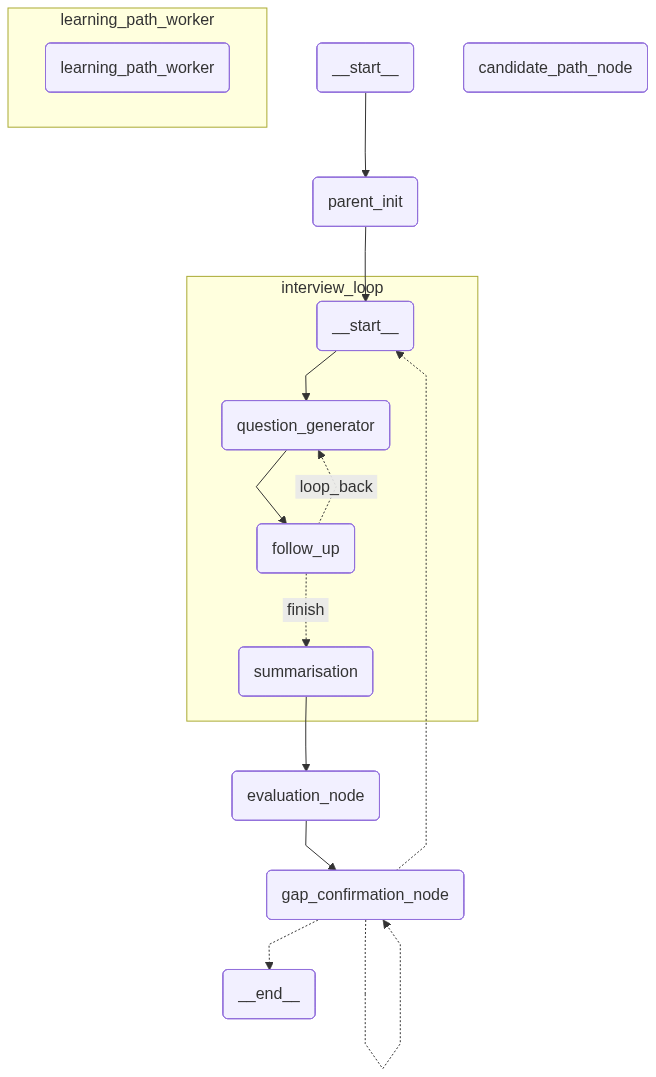

In [19]:

# Display
from IPython.display import Image, display

display(Image(parent_graph.get_graph(xray=1).draw_mermaid_png()))


In [20]:
user = {}
user["1"] = input("Whats your name: ").strip()
learner_motivation = {}
interests = {}

interests["1"] = [input("What skill are you planning to learn today: ").strip()]
learner_motivation["1"] = input("What is your motivation for learning? (job/concepts/practice): ").strip()

In [21]:
thread_id = "1"

config = {"configurable": {"thread_id": thread_id}}
learner_state = {
    "learner_profile": {
        "interests": interests[thread_id],
        "known_gaps": [],
        "learning_paths": [],

    },
    "learner_motivation": learner_motivation[thread_id],
    "interview_summary": [],
    "known_gaps": [],
    "detected_gaps": [],
    "gap_confidence_score": 1.0,
    "approval_status": "pending",
    "gap_confirmation": "pending",
    "evaluation_rationale": ""
}


In [22]:
DIVIDER = "=" * 60
# Initia Stream
print(f"\n{DIVIDER}")
for namespace, event in parent_graph.stream(learner_state, config, subgraphs=True):
    for node_name, payload in event.items():
        if not isinstance(payload, dict):
            continue
        if node_name == "question_generator" and "interview_messages" in payload:
            msgs = payload["interview_messages"]
            if msgs and getattr(msgs[-1], "type", "") in ["ai", "AIMessage"]:
                print(f"\n🤖 Mentor:\n{msgs[-1].content}")



[Parent Gate] Bootstrapping SkillForge pipeline for user.
Current interests captured: ['Cooking']

🤖 Mentor:
How do the flavor profiles of different cuisines influence your cooking style?


In [23]:


NODE_LABELS = {
    "parent_init":           "⚙️  Initialising session...",
    "interview_loop":        "💬 Interview in progress...",
    "summarisation":         "📝 Summarising your responses...",
    "evaluation_node":       "⚖️  Evaluating your responses...",
    "gap_confirmation_node": "🌱 Preparing your gap report...",
    "learning_path_worker":  "🔨 Generating learning path...",
    "candidate_path_node":   "🏆 Ranking your learning paths...",
}

# ── Resume Loop ──
while True:
    snap   = parent_graph.get_state(config)
    nexts  = str(snap.next) if snap.next else ""
    values = snap.values or {}

    # ── Session complete ──
    if not snap.next:
        print(f"\n{DIVIDER}")
        print("✅ SESSION COMPLETE")
        print(DIVIDER)

        ranked    = values.get("ranked_paths", [])
        all_paths = {p["path_id"]: p for p in values.get("candidate_learning_paths", [])}

        if ranked:
            print(f"\n🏆 TOP RECOMMENDED LEARNING PATHS\n")
            for rp in ranked:
                path = all_paths.get(rp.get("path_id", ""), {})
                print(f"{DIVIDER}")
                print(f"🥇 Rank {rp.get('rank')} — {rp.get('path_id')}")
                print(f"⭐ Score : {rp.get('score')}/100")
                print(f"💡 Why  : {rp.get('reason')}")
                print(f"🎯 Focus: {path.get('focus', '')}")
                print(f"📋 Plan :")
                for step in path.get("plan", []):
                    print(f"   • {step}")
            print(DIVIDER)

        elif all_paths:
            print(f"\n📚 GENERATED LEARNING PATHS ({len(all_paths)})\n")
            for path in all_paths.values():
                print(f"{DIVIDER}")
                print(f"📌 {path.get('path_id')}")
                print(f"🎯 Focus: {path.get('focus', '')}")
                print(f"📋 Plan :")
                for step in path.get("plan", []):
                    print(f"   • {step}")
            print(DIVIDER)
        break

    # ── Gap confirmation gate ──
    elif "gap_confirmation_node" in nexts:
        print(f"\n{DIVIDER}")
        print(values.get("gap_confirmation_message", ""))
        print(DIVIDER)
        user_input = input("\nYES or MORE: ").strip()

    # ── Interview in progress ──
    elif "interview_loop" in nexts:
        user_input = input("\nYou: ").strip()

    # ── Unexpected state — debug ──
    else:
        print(f"\n⚠️  Unexpected next state: {snap.next}")
        user_input = input("\nYou: ").strip()

    print(f"\n{DIVIDER}")

    # ── Stream with user input ──
    for namespace, event in parent_graph.stream(
        Command(resume=user_input), config, subgraphs=True
    ):
        for node_name, payload in event.items():
            if not isinstance(payload, dict):
                continue

            # ── Node entry status ──
            if node_name in NODE_LABELS:
                print(f"\n{NODE_LABELS[node_name]}")

            # ── Mentor question ──
            if node_name == "question_generator" and "interview_messages" in payload:
                msgs = payload["interview_messages"]
                if msgs and getattr(msgs[-1], "type", "") in ["ai", "AIMessage"]:
                    print(f"\n🤖 Mentor:\n{msgs[-1].content}")

            # ── Evaluation result ──
            if node_name == "evaluation_node":
                score = payload.get("gap_confidence_score")
                if score is not None:
                    print(f"   Confidence: {score:.2f}")

            # ── Worker completed ──
            if node_name == "learning_path_worker":
                paths = payload.get("candidate_learning_paths", [])
                if paths:
                    print(f"   ✅ Path ready: {paths[0].get('path_id', '')}")

            # ── Ranking complete ──
            if node_name == "candidate_path_node":
                ranked = payload.get("ranked_paths", [])
                if ranked:
                    print(f"   🥇 Top pick: {ranked[0].get('path_id')} "
                          f"(score: {ranked[0].get('score')})")



🤖 Mentor:
How do you determine the right balance of salt and spice when creating a new dish?


🤖 Mentor:
How do you think your past cooking experiences shape your current approach to experimenting with flavors?


📝 Summarising your responses...

💬 Interview in progress...

⚖️  Evaluating your responses...
   Confidence: 0.90


🌱 *Here's what we discovered about your learning journey so far...*

Your engagement and effort

**Your Growth Opportunities:**
  • While you've identified salt and spice as key flavor elements in your cooking, there's a growth opportunity to explore more systematic methods for balancing these flavors. This can help refine your approach and ensure consistency in your dishes.
  • You mentioned that experience plays a significant role in your current approach but haven't yet shared specific techniques or strategies. Exploring practical examples could enhance your culinary skills and creativity.

**Our Assessment:**
Your understanding of key flavor elements like s

KeyError: 'interest'